In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.style.use("seaborn-v0_8-whitegrid")

In [ ]:
def simulate_trajectory():
    np.random.seed(42)
    start_time = datetime(2021, 1, 25, 6, 0, 0)

    segments = []

    # 1) Straight approach
    n1 = 60
    lats1 = np.linspace(33.2, 33.4, n1)
    lngs1 = np.linspace(-118.4, -118.2, n1)
    seg1 = pd.DataFrame(
        {
            "timestamp": [start_time + timedelta(minutes=5 * i) for i in range(n1)],
            "lat": lats1,
            "lon": lngs1,
            "segment": "approach",
        }
    )
    segments.append(seg1)

    # 2) Lawn‑mower (research / survey) pattern
    n2 = 120
    base_lat, base_lng = 33.4, -118.2
    width_lat, width_lng = 0.15, 0.15
    rows = 6
    row_pts = n2 // rows
    lats2 = []
    lngs2 = []
    for r in range(rows):
        y = base_lat + (r / rows) * width_lat
        if r % 2 == 0:
            xs = np.linspace(base_lng, base_lng + width_lng, row_pts)
        else:
            xs = np.linspace(base_lng + width_lng, base_lng, row_pts)
        lats2.extend([y] * row_pts)
        lngs2.extend(xs)

    seg2_start_time = seg1["timestamp"].iloc[-1] + timedelta(minutes=5)
    seg2 = pd.DataFrame(
        {
            "timestamp": [
                seg2_start_time + timedelta(minutes=5 * i) for i in range(n2)
            ],
            "lat": lats2,
            "lon": lngs2,
            "segment": "lawn_mower",
        }
    )
    segments.append(seg2)

    # 3) Lasso (loop) pattern
    n3 = 80
    center_lat, center_lng = 33.45, -118.1
    radius = 0.05
    angles = np.linspace(0, 2 * np.pi, n3)
    lats3 = center_lat + radius * np.sin(angles)
    lngs3 = center_lng + radius * np.cos(angles)

    seg3_start_time = seg2["timestamp"].iloc[-1] + timedelta(minutes=5)
    seg3 = pd.DataFrame(
        {
            "timestamp": [
                seg3_start_time + timedelta(minutes=5 * i) for i in range(n3)
            ],
            "lat": lats3,
            "lon": lngs3,
            "segment": "lasso",
        }
    )
    segments.append(seg3)

    # 4) Zig‑zag pattern
    n4 = 80
    lats4 = np.linspace(33.45, 33.55, n4)
    zig = 0.05 * np.sign(np.sin(np.linspace(0, 10 * np.pi, n4)))
    lngs4 = -118.05 + zig

    seg4_start_time = seg3["timestamp"].iloc[-1] + timedelta(minutes=5)
    seg4 = pd.DataFrame(
        {
            "timestamp": [
                seg4_start_time + timedelta(minutes=5 * i) for i in range(n4)
            ],
            "lat": lats4,
            "lon": lngs4,
            "segment": "zigzag",
        }
    )
    segments.append(seg4)

    traj = pd.concat(segments, ignore_index=True)
    return traj


traj = simulate_trajectory()
traj.head(), traj.tail(), traj["segment"].value_counts()

(            timestamp        lat         lon   segment
 0 2021-01-25 06:00:00  33.200000 -118.400000  approach
 1 2021-01-25 06:05:00  33.203390 -118.396610  approach
 2 2021-01-25 06:10:00  33.206780 -118.393220  approach
 3 2021-01-25 06:15:00  33.210169 -118.389831  approach
 4 2021-01-25 06:20:00  33.213559 -118.386441  approach,
               timestamp        lat    lon segment
 335 2021-01-26 09:55:00  33.544937 -118.1  zigzag
 336 2021-01-26 10:00:00  33.546203 -118.1  zigzag
 337 2021-01-26 10:05:00  33.547468 -118.1  zigzag
 338 2021-01-26 10:10:00  33.548734 -118.1  zigzag
 339 2021-01-26 10:15:00  33.550000 -118.1  zigzag,
 segment
 lawn_mower    120
 lasso          80
 zigzag         80
 approach       60
 Name: count, dtype: int64)

In [ ]:
from math import radians, cos, sin, asin, sqrt


def haversine(lat1, lon1, lat2, lon2):
    # distance in nautical miles (approx)
    R = 3440.065
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * asin(sqrt(a))
    return R * c


def trajectory_redundancy(df):
    if len(df) < 2:
        return 0.0
    # total path length
    dists = [
        haversine(
            df["lat"].iloc[i],
            df["lon"].iloc[i],
            df["lat"].iloc[i + 1],
            df["lon"].iloc[i + 1],
        )
        for i in range(len(df) - 1)
    ]
    D = np.sum(dists)
    # bounding rectangle perimeter
    min_lat, max_lat = df["lat"].min(), df["lat"].max()
    min_lon, max_lon = df["lon"].min(), df["lon"].max()
    # approximate rectangle edges with haversine at mid‑lat
    height = haversine(min_lat, min_lon, max_lat, min_lon)
    width = haversine(min_lat, min_lon, min_lat, max_lon)
    P = 2 * (height + width)
    if P == 0:
        return 0.0
    return D / P

In [ ]:
def compute_loitering_scores(traj, window_hours=6, step_minutes=30):
    traj = traj.sort_values("timestamp").reset_index(drop=True)
    start = traj["timestamp"].min()
    end = traj["timestamp"].max()

    window = timedelta(hours=window_hours)
    step = timedelta(minutes=step_minutes)

    scores = []
    t = start
    while t + window <= end:
        mask = (traj["timestamp"] >= t) & (traj["timestamp"] < t + window)
        df_win = traj[mask]
        psi = trajectory_redundancy(df_win)
        scores.append({"window_start": t, "window_end": t + window, "psi": psi})
        t += step

    scores_df = pd.DataFrame(scores)
    return scores_df


scores_df = compute_loitering_scores(traj, window_hours=6, step_minutes=30)
scores_df.head(), scores_df["psi"].max()

(         window_start          window_end       psi
 0 2021-01-25 06:00:00 2021-01-25 12:00:00  0.378573
 1 2021-01-25 06:30:00 2021-01-25 12:30:00  0.391403
 2 2021-01-25 07:00:00 2021-01-25 13:00:00  0.426175
 3 2021-01-25 07:30:00 2021-01-25 13:30:00  0.481526
 4 2021-01-25 08:00:00 2021-01-25 14:00:00  0.548114,
 np.float64(2.391919933190914))

In [ ]:
max_row = scores_df.loc[scores_df["psi"].idxmax()]
max_row

window_start    2021-01-26 04:00:00
window_end      2021-01-26 10:00:00
psi                         2.39192
Name: 44, dtype: object

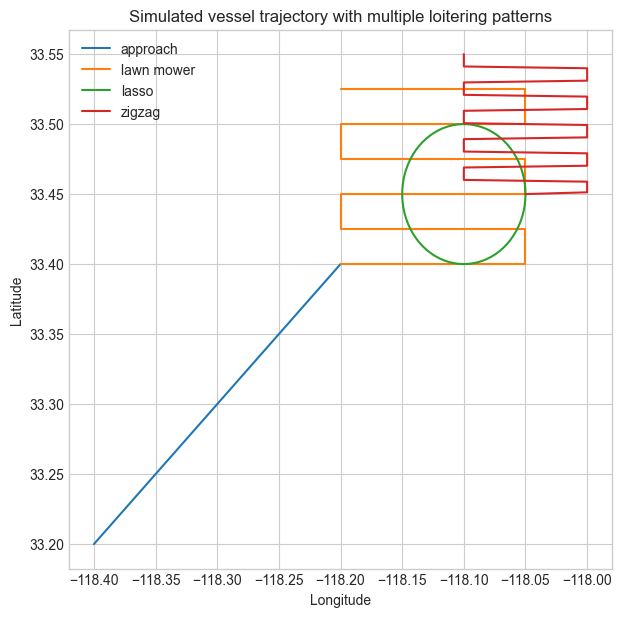

In [ ]:
def plot_2d_traj(traj):
    fig, ax = plt.subplots(figsize=(7, 7))
    segments = traj["segment"].unique()
    colors = {
        "approach": "tab:blue",
        "lawn_mower": "tab:orange",
        "lasso": "tab:green",
        "zigzag": "tab:red",
    }
    for seg in segments:
        df = traj[traj["segment"] == seg]
        ax.plot(
            df["lon"],
            df["lat"],
            label=seg.replace("_", " "),
            color=colors.get(seg, "k"),
        )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Simulated vessel trajectory with multiple loitering patterns")
    ax.legend()
    plt.show()


plot_2d_traj(traj)

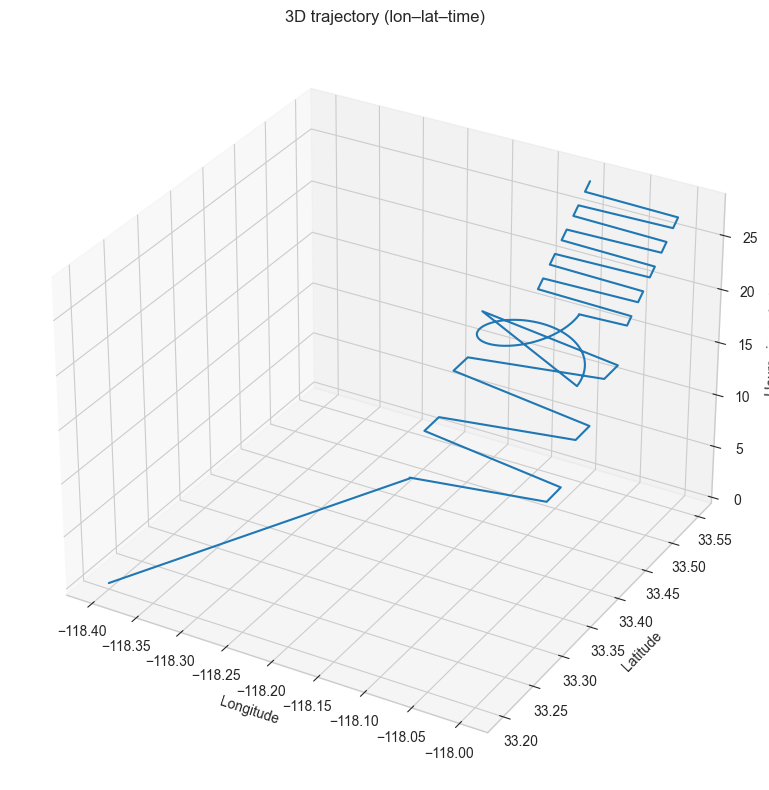

In [ ]:
def plot_3d_traj(traj):
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    # numeric time axis (hours since start)
    t0 = traj["timestamp"].min()
    t_hours = (traj["timestamp"] - t0).dt.total_seconds() / 3600.0

    sc = ax.plot(traj["lon"], traj["lat"], t_hours, color="tab:blue")

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_zlabel("Hours since start")
    ax.set_title("3D trajectory (lon–lat–time)")
    plt.tight_layout()
    plt.show()


plot_3d_traj(traj)

C:\Users\amans\AppData\Local\Temp\ipykernel_27068\548273771.py:30: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
f:\PyTorch_GPU\torch_gpu\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


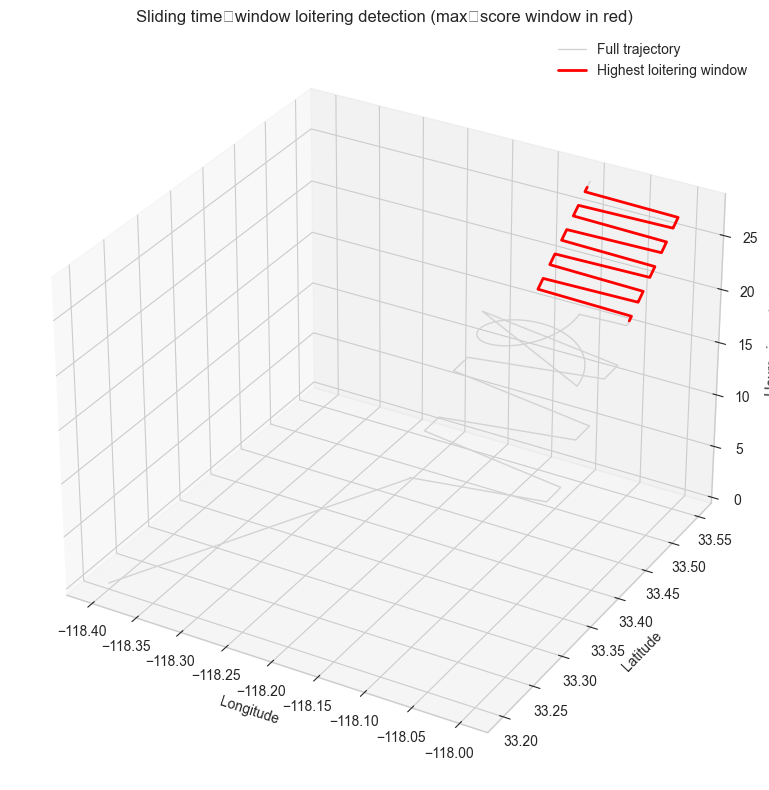

In [ ]:
def plot_loitering_window_3d(traj, scores_df, row=None):
    if row is None:
        row = scores_df.loc[scores_df["psi"].idxmax()]

    w_start, w_end = row["window_start"], row["window_end"]

    t0 = traj["timestamp"].min()
    traj_all = traj.copy()
    traj_all["t_hours"] = (traj_all["timestamp"] - t0).dt.total_seconds() / 3600.0

    mask = (traj_all["timestamp"] >= w_start) & (traj_all["timestamp"] < w_end)
    traj_win = traj_all[mask]

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    # full trajectory in light color
    ax.plot(
        traj_all["lon"],
        traj_all["lat"],
        traj_all["t_hours"],
        color="lightgray",
        linewidth=1,
        label="Full trajectory",
    )

    # highlighted window
    ax.plot(
        traj_win["lon"],
        traj_win["lat"],
        traj_win["t_hours"],
        color="red",
        linewidth=2,
        label="Highest loitering window",
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_zlabel("Hours since start")
    ax.set_title("Sliding time‑window loitering detection (max‑score window in red)")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_loitering_window_3d(traj, scores_df)

In [ ]:
def plot_loitering_window_3d(traj, scores_df, row=None):
    if row is None:
        row = scores_df.loc[scores_df["psi"].idxmax()]

    w_start, w_end = row["window_start"], row["window_end"]

    t0 = traj["timestamp"].min()
    traj_all = traj.copy()
    traj_all["t_hours"] = (traj_all["timestamp"] - t0).dt.total_seconds() / 3600.0

    mask = (traj_all["timestamp"] >= w_start) & (traj_all["timestamp"] < w_end)
    traj_win = traj_all[mask]

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    # full trajectory in light color
    ax.plot(
        traj_all["lon"],
        traj_all["lat"],
        traj_all["t_hours"],
        color="lightgray",
        linewidth=1,
        label="Full trajectory",
    )

    # highlighted window
    ax.plot(
        traj_win["lon"],
        traj_win["lat"],
        traj_win["t_hours"],
        color="red",
        linewidth=2,
        label="Highest loitering window",
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_zlabel("Hours since start")
    ax.set_title("Sliding time‑window loitering detection (max‑score window in red)")
    ax.legend()
    plt.tight_layout()
    plt.show()

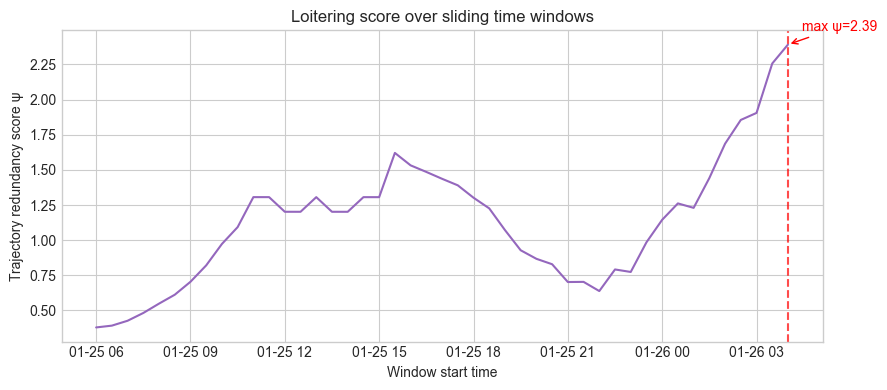

In [ ]:
def plot_loitering_score(scores_df):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(scores_df["window_start"], scores_df["psi"], color="tab:purple")
    ax.set_xlabel("Window start time")
    ax.set_ylabel("Trajectory redundancy score ψ")
    ax.set_title("Loitering score over sliding time windows")
    ax.grid(True)

    # mark maximum
    max_row = scores_df.loc[scores_df["psi"].idxmax()]
    ax.axvline(max_row["window_start"], color="red", linestyle="--", alpha=0.7)
    ax.annotate(
        f"max ψ={max_row['psi']:.2f}",
        xy=(max_row["window_start"], max_row["psi"]),
        xytext=(10, 10),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color="red"),
        color="red",
    )
    plt.tight_layout()
    plt.show()


plot_loitering_score(scores_df)

C:\Users\amans\AppData\Local\Temp\ipykernel_27068\3510797708.py:35: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  anim = FuncAnimation(fig, update, frames=len(scores_df),
MovieWriter ffmpeg unavailable; using Pillow instead.


ValueError: unknown file extension: .mp4

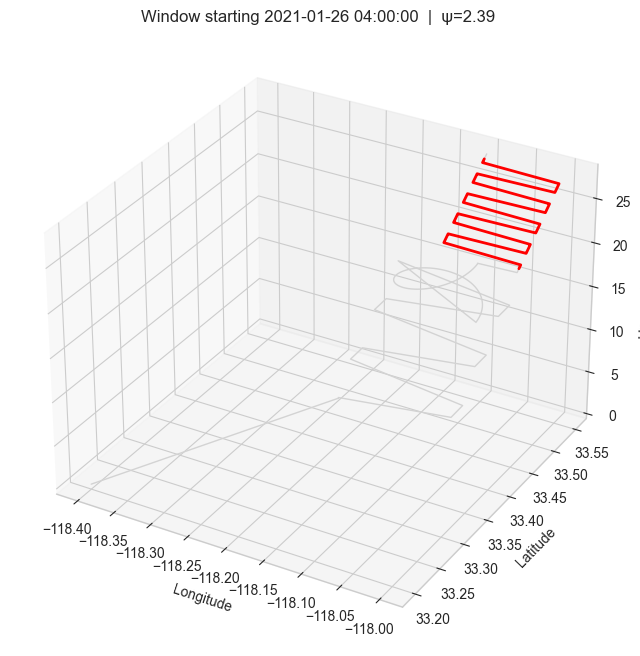

In [ ]:
def make_sliding_window_animation(traj, scores_df, filename="loitering_window.mp4"):
    traj = traj.sort_values("timestamp").reset_index(drop=True)
    t0 = traj["timestamp"].min()
    traj["t_hours"] = (traj["timestamp"] - t0).dt.total_seconds() / 3600.0

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    # static full trajectory
    ax.plot(traj["lon"], traj["lat"], traj["t_hours"], color="lightgray", linewidth=1)

    (line_window,) = ax.plot([], [], [], color="red", linewidth=2)

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_zlabel("Hours since start")
    ax.set_title("Sliding time‑window loitering visualization")

    def init():
        line_window.set_data([], [])
        line_window.set_3d_properties([])
        return (line_window,)

    def update(frame):
        row = scores_df.iloc[frame]
        w_start, w_end = row["window_start"], row["window_end"]
        mask = (traj["timestamp"] >= w_start) & (traj["timestamp"] < w_end)
        df_win = traj[mask]
        line_window.set_data(df_win["lon"], df_win["lat"])
        line_window.set_3d_properties(df_win["t_hours"])
        ax.set_title(f"Window starting {w_start}  |  ψ={row['psi']:.2f}")
        return (line_window,)

    anim = FuncAnimation(
        fig, update, frames=len(scores_df), init_func=init, blit=True, interval=200
    )

    # Save (requires ffmpeg installed for mp4)
    anim.save(filename, fps=5)
    plt.close(fig)
    return filename


# This will write an mp4 in the working directory
make_sliding_window_animation(traj, scores_df, "loitering_window.mp4")

In [ ]:
def plot_loitering_window_3d(traj, scores_df, row=None):
    if row is None:
        row = scores_df.loc[scores_df["psi"].idxmax()]

    w_start, w_end = row["window_start"], row["window_end"]

    t0 = traj["timestamp"].min()
    traj_all = traj.copy()
    traj_all["t_hours"] = (traj_all["timestamp"] - t0).dt.total_seconds() / 3600.0

    mask = (traj_all["timestamp"] >= w_start) & (traj_all["timestamp"] < w_end)
    traj_win = traj_all[mask]

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    # full trajectory in light color
    ax.plot(
        traj_all["lon"],
        traj_all["lat"],
        traj_all["t_hours"],
        color="lightgray",
        linewidth=1,
        label="Full trajectory",
    )

    # highlighted window
    ax.plot(
        traj_win["lon"],
        traj_win["lat"],
        traj_win["t_hours"],
        color="red",
        linewidth=2,
        label="Highest loitering window",
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_zlabel("Hours since start")
    ax.set_title("Sliding time‑window loitering detection (max‑score window in red)")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np


def plot_loitering_windows_2d_and_score(traj, scores_df, n_colors=10):
    """
    2D map:
      - grey base trajectory
      - each time window drawn in its own color

    Score plot:
      - ψ(t) per window, same colors as 2D windows
    """

    traj = traj.sort_values("timestamp").reset_index(drop=True)
    scores_df = scores_df.sort_values("window_start").reset_index(drop=True)

    # choose a colormap and generate colors per window
    cmap = plt.get_cmap("tab20")  # or "viridis", "plasma", etc.
    n_win = len(scores_df)
    colors = [cmap(i % n_colors) for i in range(n_win)]

    fig, (ax_map, ax_score) = plt.subplots(
        2, 1, figsize=(10, 10), gridspec_kw={"height_ratios": [2, 1]}
    )

    # ---------- 2D map with colored windows ----------
    # base trajectory in light grey
    ax_map.plot(
        traj["lon"],
        traj["lat"],
        color="lightgray",
        linewidth=1,
        label="Full trajectory",
    )

    for idx, row in scores_df.iterrows():
        w_start, w_end, psi = row["window_start"], row["window_end"], row["psi"]
        mask = (traj["timestamp"] >= w_start) & (traj["timestamp"] < w_end)
        df_win = traj[mask]
        if df_win.empty:
            continue
        ax_map.plot(
            df_win["lon"],
            df_win["lat"],
            color=colors[idx],
            linewidth=2,
            label=f"window {idx} (ψ={psi:.2f})" if idx < n_colors else None,
        )

    ax_map.set_xlabel("Longitude")
    ax_map.set_ylabel("Latitude")
    ax_map.set_title("2D trajectory with colored time windows")

    # avoid duplicate legend entries
    handles, labels = ax_map.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax_map.legend(uniq.values(), uniq.keys(), fontsize=8, loc="best")

    # ---------- loitering score plot ----------
    ax_score.plot(
        scores_df["window_start"],
        scores_df["psi"],
        color="lightgray",
        linewidth=1,
        marker="o",
        markersize=3,
        label="ψ (all windows)",
    )

    # draw each window as a colored segment on the score curve
    for idx, row in scores_df.iterrows():
        w_start, psi = row["window_start"], row["psi"]
        ax_score.plot(w_start, psi, marker="o", color=colors[idx], markersize=6)

    ax_score.set_xlabel("Window start time")
    ax_score.set_ylabel("Trajectory redundancy ψ")
    ax_score.set_title("Loitering score per time window")

    # nicer time formatting on x‑axis
    ax_score.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
    fig.autofmt_xdate()

    plt.tight_layout()
    plt.show()

C:\Users\amans\AppData\Local\Temp\ipykernel_27068\210658302.py:30: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
f:\PyTorch_GPU\torch_gpu\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


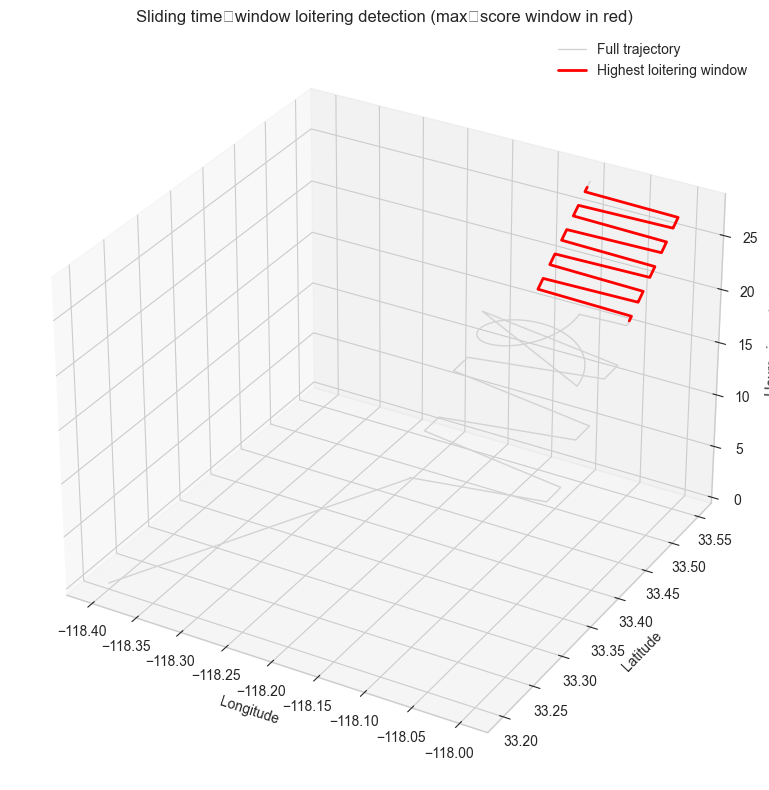

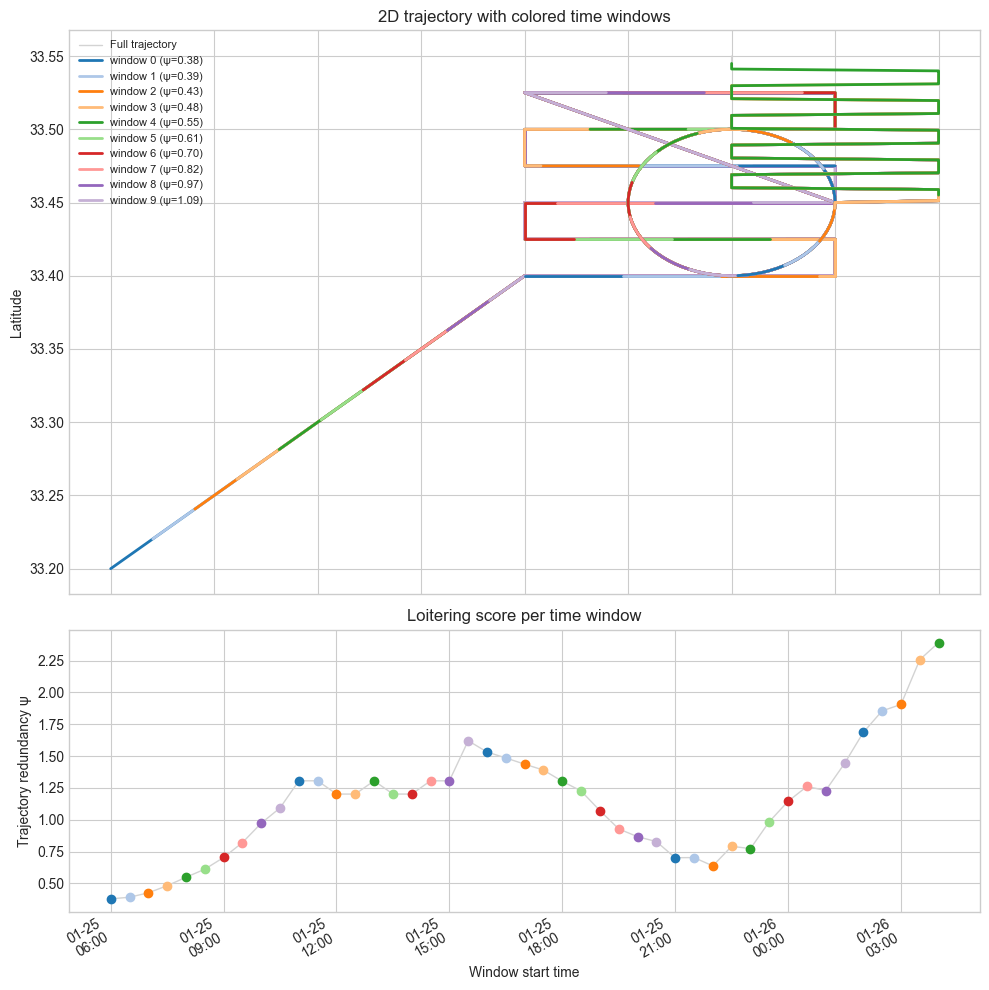

In [ ]:
plot_loitering_window_3d(traj, scores_df)  # 3D view of max-ψ window
plot_loitering_windows_2d_and_score(traj, scores_df)  # 2D windows + ψ plot

In [ ]:
def generate_long_alternating_traj(
    start_time=datetime(2021, 1, 1, 0, 0, 0),
    n_cycles=6,
    normal_points=120,  # length of each normal leg
    zigzag_points=80,  # length of each zig‑zag leg
    dt_minutes=5,
):
    """
    Build a long trajectory where the vessel alternates between
    normal straight motion and local zig‑zag ‘loitering’ around the track.
    """

    timestamps = []
    lats = []
    lons = []
    labels = []

    # starting position and heading
    lat, lon = 20.0, 70.0
    heading_lat_step = 0.01  # drift per point during normal motion
    heading_lon_step = 0.02

    t = start_time

    for cycle in range(n_cycles):
        # ---- 1) normal straight movement ----
        for i in range(normal_points):
            lat += heading_lat_step
            lon += heading_lon_step
            timestamps.append(t)
            lats.append(lat)
            lons.append(lon)
            labels.append(f"normal_{cycle}")
            t += timedelta(minutes=dt_minutes)

        # center point where zig‑zag is performed
        center_lat, center_lon = lat, lon

        # ---- 2) local zig‑zag around current position ----
        # zig‑zag amplitude and frequency
        amp_lat = 0.03
        amp_lon = 0.06
        zig_phase = np.linspace(0, 6 * np.pi, zigzag_points)

        for k in range(zigzag_points):
            # move forward a little but oscillate left/right
            lat = center_lat + amp_lat * np.sin(zig_phase[k])
            lon = center_lon + amp_lon * np.sign(np.sin(zig_phase[k]))
            timestamps.append(t)
            lats.append(lat)
            lons.append(lon)
            labels.append(f"zigzag_{cycle}")
            t += timedelta(minutes=dt_minutes)

        # after zig‑zag, resume from last position and continue in same main heading
        # (this keeps the track continuous and moving forward)

    traj = pd.DataFrame(
        {"timestamp": timestamps, "lat": lats, "lon": lons, "phase": labels}
    )
    return traj


traj_long = generate_long_alternating_traj()
traj_long.head(), traj_long.tail(), traj_long["phase"].value_counts()

(            timestamp    lat    lon     phase
 0 2021-01-01 00:00:00  20.01  70.02  normal_0
 1 2021-01-01 00:05:00  20.02  70.04  normal_0
 2 2021-01-01 00:10:00  20.03  70.06  normal_0
 3 2021-01-01 00:15:00  20.04  70.08  normal_0
 4 2021-01-01 00:20:00  20.05  70.10  normal_0,
                timestamp        lat    lon     phase
 1195 2021-01-05 03:35:00  27.175521  84.04  zigzag_5
 1196 2021-01-05 03:40:00  27.180313  84.04  zigzag_5
 1197 2021-01-05 03:45:00  27.186221  84.04  zigzag_5
 1198 2021-01-05 03:50:00  27.192910  84.04  zigzag_5
 1199 2021-01-05 03:55:00  27.200000  84.04  zigzag_5,
 phase
 normal_0    120
 normal_1    120
 normal_3    120
 normal_2    120
 normal_5    120
 normal_4    120
 zigzag_1     80
 zigzag_0     80
 zigzag_3     80
 zigzag_2     80
 zigzag_4     80
 zigzag_5     80
 Name: count, dtype: int64)

C:\Users\amans\AppData\Local\Temp\ipykernel_28976\55711418.py:14: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
f:\PyTorch_GPU\torch_gpu\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


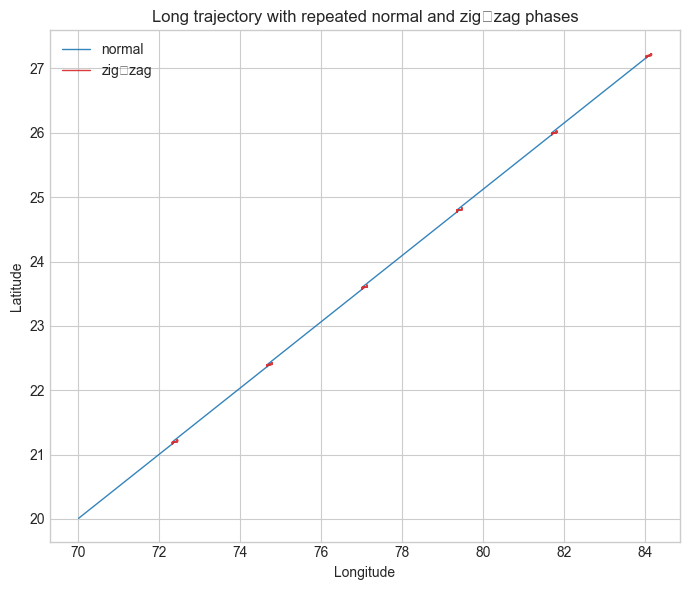

In [ ]:
def plot_2d_long(traj):
    fig, ax = plt.subplots(figsize=(7, 6))
    for phase, df in traj.groupby("phase"):
        color = "tab:blue" if "normal" in phase else "tab:red"
        ax.plot(
            df["lon"],
            df["lat"],
            color=color,
            linewidth=1,
            alpha=0.9,
            label="normal" if "normal" in phase else "zig‑zag",
        )
    # avoid duplicate labels
    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys())
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Long trajectory with repeated normal and zig‑zag phases")
    plt.tight_layout()
    plt.show()


plot_2d_long(traj_long)

C:\Users\amans\AppData\Local\Temp\ipykernel_28976\2987117749.py:24: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
f:\PyTorch_GPU\torch_gpu\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


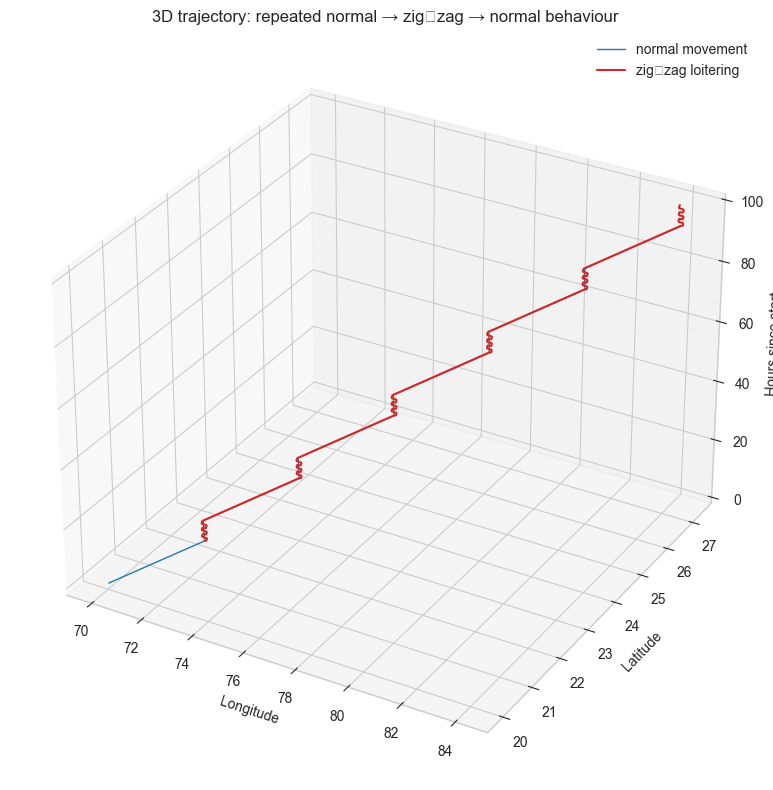

In [ ]:
def plot_3d_long(traj):
    traj = traj.sort_values("timestamp").reset_index(drop=True)
    t0 = traj["timestamp"].min()
    traj["t_hours"] = (traj["timestamp"] - t0).dt.total_seconds() / 3600.0

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    # normal and zig‑zag in different colours
    mask_zig = traj["phase"].str.contains("zigzag")
    df_norm = traj[~mask_zig]
    df_zig = traj[mask_zig]

    ax.plot(
        df_norm["lon"],
        df_norm["lat"],
        df_norm["t_hours"],
        color="tab:blue",
        linewidth=1,
        label="normal movement",
    )
    ax.plot(
        df_zig["lon"],
        df_zig["lat"],
        df_zig["t_hours"],
        color="tab:red",
        linewidth=1.5,
        label="zig‑zag loitering",
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_zlabel("Hours since start")
    ax.set_title("3D trajectory: repeated normal → zig‑zag → normal behaviour")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_3d_long(traj_long)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import numpy as np


def animate_long_traj(traj, filename="long_traj_zigzag.gif", max_frames=400, fps=20):
    # sort & compute time axis
    traj = traj.sort_values("timestamp").reset_index(drop=True)
    t0 = traj["timestamp"].min()
    traj["t_hours"] = (traj["timestamp"] - t0).dt.total_seconds() / 3600.0

    # ---- down‑sample frames so animation is not huge ----
    n = len(traj)
    if n > max_frames:
        step = int(np.ceil(n / max_frames))
        frame_indices = np.arange(0, n, step)
    else:
        frame_indices = np.arange(n)

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    (line_norm,) = ax.plot([], [], [], color="tab:blue", linewidth=1, label="normal")
    (line_zig,) = ax.plot([], [], [], color="tab:red", linewidth=1.5, label="zig‑zag")

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_zlabel("Hours since start")
    ax.set_title("Growing trajectory with repeated zig‑zag loitering")
    ax.legend(loc="upper left")

    def init():
        line_norm.set_data([], [])
        line_norm.set_3d_properties([])
        line_zig.set_data([], [])
        line_zig.set_3d_properties([])
        return line_norm, line_zig

    def update(i):
        # i is an index in frame_indices
        idx = frame_indices[i]
        df = traj.iloc[: idx + 1]

        mask_zig = df["phase"].str.contains("zigzag")
        df_norm = df[~mask_zig]
        df_zig = df[mask_zig]

        line_norm.set_data(df_norm["lon"], df_norm["lat"])
        line_norm.set_3d_properties(df_norm["t_hours"])

        line_zig.set_data(df_zig["lon"], df_zig["lat"])
        line_zig.set_3d_properties(df_zig["t_hours"])

        return line_norm, line_zig

    anim = FuncAnimation(
        fig,
        update,
        frames=len(frame_indices),
        init_func=init,
        blit=False,  # blit can be problematic with 3D
        interval=1000 / fps,
    )

    # ---- save as GIF using Pillow writer (no ffmpeg needed) ----
    if filename.lower().endswith(".gif"):
        writer = PillowWriter(fps=fps)
        anim.save(filename, writer=writer)
    else:
        # if you really want MP4, make sure ffmpeg is installed and use:
        # from matplotlib.animation import FFMpegWriter
        # writer = FFMpegWriter(fps=fps)
        # anim.save(filename, writer=writer)
        raise ValueError("Use .gif extension unless you set up an MP4 writer.")

    plt.close(fig)
    return filename


# example call (traj_long is your DataFrame)
animate_long_traj(traj_long, "long_traj_zigzag.gif", max_frames=400, fps=20)

C:\Users\amans\AppData\Local\Temp\ipykernel_28976\3196056567.py:69: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  anim.save(filename, writer=writer)


'long_traj_zigzag.gif'

In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.style.use("seaborn-v0_8-whitegrid")

In [ ]:
def simulate_vessel_with_switching(
    start_time=datetime(2021, 1, 1, 0, 0, 0),
    n_cycles=8,
    normal_points=150,  # points in each normal leg
    zigzag_points=100,  # points in each zig‑zag leg
    dt_minutes=5,
):
    """
    Simulate a long vessel trajectory that repeatedly switches
    between normal straight motion and zig‑zag 'loitering'.

    Returns a DataFrame with columns:
      timestamp, lat, lon, phase  (phase ∈ {'normal_k','zigzag_k'})
    """

    timestamps, lats, lons, phases = [], [], [], []

    # initial state and main heading (roughly NE)
    lat, lon = 20.0, 70.0
    dlat_normal = 0.01  # degrees per step
    dlon_normal = 0.02
    t = start_time

    for cycle in range(n_cycles):

        # ---------- normal leg ----------
        for i in range(normal_points):
            lat += dlat_normal
            lon += dlon_normal
            timestamps.append(t)
            lats.append(lat)
            lons.append(lon)
            phases.append(f"normal_{cycle}")
            t += timedelta(minutes=dt_minutes)

        # center of upcoming zig‑zag “loitering” episode
        center_lat, center_lon = lat, lon

        # ---------- zig‑zag leg ----------
        amp_lat = 0.03
        amp_lon = 0.06
        phase_grid = np.linspace(0, 6 * np.pi, zigzag_points)

        for k in range(zigzag_points):
            # oscillate around center while still drifting forward slightly
            lat = center_lat + amp_lat * np.sin(phase_grid[k])
            lon = center_lon + amp_lon * np.sign(np.sin(phase_grid[k]))
            timestamps.append(t)
            lats.append(lat)
            lons.append(lon)
            phases.append(f"zigzag_{cycle}")
            t += timedelta(minutes=dt_minutes)

        # after zig‑zag, continue from last position in same main heading
        # so the whole track drifts across the map as time goes on

    traj = pd.DataFrame(
        {"timestamp": timestamps, "lat": lats, "lon": lons, "phase": phases}
    )
    return traj


traj = simulate_vessel_with_switching()
traj.head()

,timestamp,lat,lon,phase
0,2021-01-01 00:00:00,20.01,70.02,normal_0
1,2021-01-01 00:05:00,20.02,70.04,normal_0
2,2021-01-01 00:10:00,20.03,70.06,normal_0
3,2021-01-01 00:15:00,20.04,70.08,normal_0
4,2021-01-01 00:20:00,20.05,70.10,normal_0


C:\Users\amans\AppData\Local\Temp\ipykernel_28976\3070668990.py:23: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
f:\PyTorch_GPU\torch_gpu\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


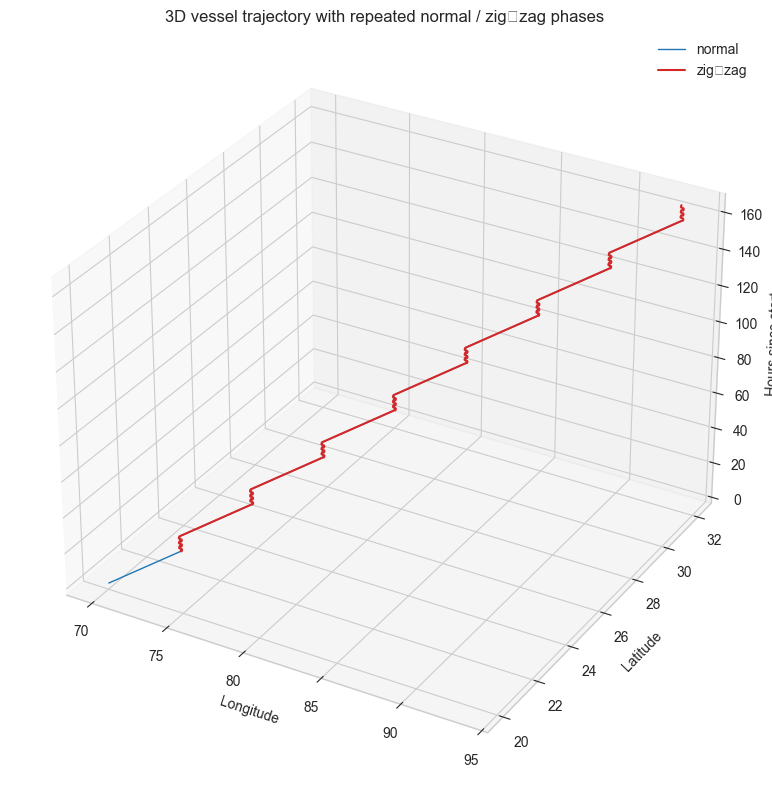

In [ ]:
def plot_3d_trajectory(traj):
    traj = traj.sort_values("timestamp").reset_index(drop=True)
    t0 = traj["timestamp"].min()
    traj["t_hours"] = (traj["timestamp"] - t0).dt.total_seconds() / 3600.0

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    mask_zig = traj["phase"].str.contains("zigzag")
    df_norm = traj[~mask_zig]
    df_zig = traj[mask_zig]

    ax.plot(
        df_norm["lon"],
        df_norm["lat"],
        df_norm["t_hours"],
        color="tab:blue",
        linewidth=1,
        label="normal",
    )
    ax.plot(
        df_zig["lon"],
        df_zig["lat"],
        df_zig["t_hours"],
        color="tab:red",
        linewidth=1.5,
        label="zig‑zag",
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_zlabel("Hours since start")
    ax.set_title("3D vessel trajectory with repeated normal / zig‑zag phases")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_3d_trajectory(traj)